# What drives the price of a car?

![](plots/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = plots/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [1]:
comment="""

Our aim is to identify what factors influence used car prices.
To do so, we will first build a regression model and verify it with the existing data (from data/vehicles.csv),
then we will use the predictions from this model for different parameters choices,
to see how the model's price predictions vary with these parameters.

In doing so, we aim to identify key parameter values that are correlated with higher prices (hence to be preferred in inventory),
or with lower prices (hence to be avoided in inventory).

"""

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [2]:
# Read in the data:

import pandas as pd

df = pd.read_csv('data/vehicles.csv')


# Let us get an understanding of what features there are and what missing values they have.
print('Table of data features, and the percent of rows having missing values for them:')
print( df.isna().sum() * 100. / len(df) ) # Get percentage of missing values in each feature
comment=""" 
Output:
id               0.000000
region           0.000000
price            0.000000
year             0.282281
manufacturer     4.133714
model            1.236179
condition       40.785232
cylinders       41.622470
fuel             0.705819
odometer         1.030735
title_status     1.930753
transmission     0.598763
VIN             37.725356
drive           30.586347
size            71.767476
type            21.752717
paint_color     30.501078
state            0.000000
"""

# Get the number of unique values in each categorical feature.
print('---------------------')
categorical_cols = ['region','model','state','manufacturer','fuel','title_status','transmission',
                    'paint_color', 'drive', 'type', 'cylinders', 'condition']
for c in categorical_cols: 
    print(f'Feature {c} has {df[c].nunique()} unique vals')
comment=""" 
Output:
Feature region has 404 unique vals
Feature model has 29649 unique vals
Feature state has 51 unique vals
Feature manufacturer has 42 unique vals
Feature fuel has 5 unique vals
Feature title_status has 6 unique vals
Feature transmission has 3 unique vals
Feature paint_color has 12 unique vals
Feature drive has 3 unique vals
Feature type has 13 unique vals
Feature cylinders has 8 unique vals
Feature condition has 6 unique vals
"""



Table of data features, and the percent of rows having missing values for them:
id               0.000000
region           0.000000
price            0.000000
year             0.282281
manufacturer     4.133714
model            1.236179
condition       40.785232
cylinders       41.622470
fuel             0.705819
odometer         1.030735
title_status     1.930753
transmission     0.598763
VIN             37.725356
drive           30.586347
size            71.767476
type            21.752717
paint_color     30.501078
state            0.000000
dtype: float64
---------------------
Feature region has 404 unique vals
Feature model has 29649 unique vals
Feature state has 51 unique vals
Feature manufacturer has 42 unique vals
Feature fuel has 5 unique vals
Feature title_status has 6 unique vals
Feature transmission has 3 unique vals
Feature paint_color has 12 unique vals
Feature drive has 3 unique vals
Feature type has 13 unique vals
Feature cylinders has 8 unique vals
Feature condition has 6

In [3]:
comment="""

-- Overview of preliminary analysis of each feature --


- We will drop / not use the following features because, practically, they should not affect the price:
    id, VIN

- We will drop the following other features:
    size (this is missing in 70% of rows, and anyway 'model' should provide just as much information)


- The following numeric features will be kept:
    year, odometer

- The following categorical features will be kept: (below, "cardinality" means the number of unique values)
    very high cardinality, few missing vals: region, model
    low cardinality,  few missing vals: fuel, title_status, transmission
    low cardinality, many missing vals: paint_color, drive, type, cylinders, condition


"""

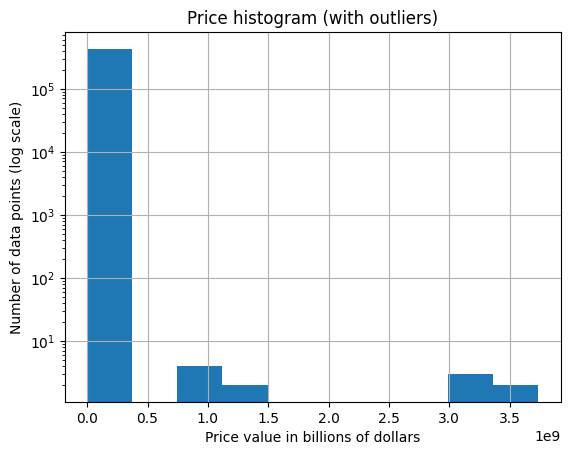

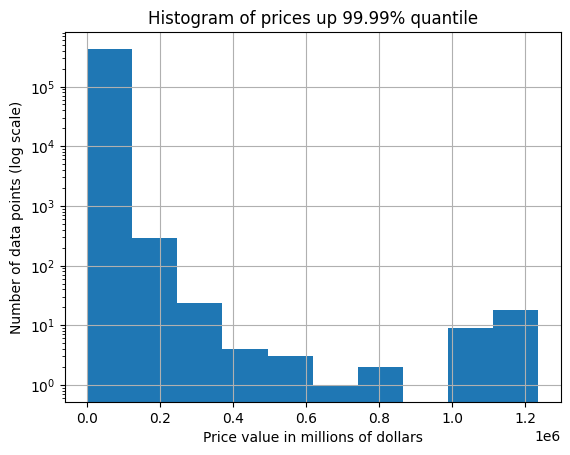

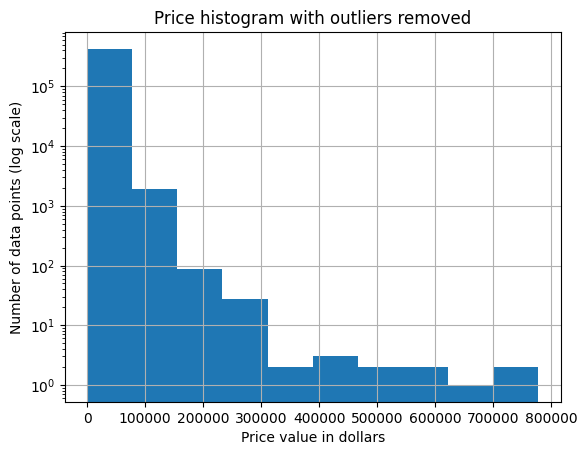

---------------------
Percentage of rows with price=0.0 : 7.705912668665667


In [4]:
## Investigating the price column for cleaning

import matplotlib.pyplot as plt

price_series = df['price']

# Let us look at a histogram of the 'price' column. We'll use a log scale on the y-column.
graph = price_series.hist(log=True) # resulting range is $0 to $4B
plt.title('Price histogram (with outliers)'); plt.xlabel('Price value in billions of dollars'); plt.ylabel('Number of data points (log scale)'); plt.show()
graph.get_figure().savefig('plots/price_histogram_showing_large_outliers.png')
comment="""
 Based on the above, there seem to be a lot of data points with large outlying values in price. 
 These are likely due to unreliable or incorrect data. (For example, if we examine them, many of these price values look like '987654321' or '123456789'.)
 To get rid of these outliers, we will first try restricting the price column to a certain quantile range.
"""

# Let us try a 99.99% quantile bound and see the resulting histogram.
price_restricted = price_series[ price_series.between(0 , price_series.quantile(0.9999)) ].copy()
plt.title('Histogram of prices up 99.99% quantile'); graph = price_restricted.hist(log=True) # resulting range is $0 to $1.3M
plt.xlabel('Price value in millions of dollars'); plt.ylabel('Number of data points (log scale)'); plt.show()
graph.get_figure().savefig('plots/price_histogram_99.99%quantile.png')
comment="""

 The resulting graph shows price frequency decreasing reasonably until about $900k.
 Then there is a sudden gap, followed by an unexpected larger frequency of prices of $1M+.
 
 Based on this gap, which is probably the start of the unreliable price data, 
 it seems to make sense to restrict to prices <= $900k.

 So when we prepare the data, we will use $900k as the threshold for outliers.
 
"""

# Let us see a histogram of prices with outliers (using our $900k threshold) removed.
price_restricted = price_series[ price_series.between(0 , 900e3) ].copy()
plt.title('Price histogram with outliers removed'); graph = price_restricted.hist(log=True) # resulting range is $0 to $800k
plt.xlabel('Price value in dollars'); plt.ylabel('Number of data points (log scale)'); plt.show()
graph.get_figure().savefig('plots/price_histogram_outliers_removed.png')
comment="""

 With outliers removed, the price distribution (in log scale) shows a more reasonable decay.

 Note: since the distribution is right-skewed, we plan to log-scale the price before fitting our regression model.
 
"""




## Next, it seems the price column has many zero values.
# These are likely due to missing data, so we will drop rows with zero listed price.
# (Note: if we fill in these values with a learned model's prediction, using these for further training would basically be like the model feeding itself its own answers.)
# Let us check the percentage of rows having zero listed price.
print('---------------------')
print(f'Percentage of rows with price=0.0 : {100. * len(df[df['price']==0.0]) / len(df)}')
comment="""
Output:
Percentage of rows with price=0.0 : 7.7
"""
# We will remove these rows with missing (actually zero) price.



In [5]:
## Some more things to check

# Let us find the range of the 'year' column. We will rescale this later.
print('---------------------')
print(f'Min and max of \'year\' column are {df['year'].min()} and {df['year'].max()}')
comment="""
Output:
Min and max of 'year' column are 1900.0 and 2022.0
"""


# Let us check to see if any regions with the same name occur in multiple states.
print('---------------------')
region_list = df['region'].unique()
print(f'Number of region names occurring in more than one state: {
    len( [ r for r in region_list if df[ df['region'] == r ]['state'].nunique() > 1 ] )
}')
comment="""
Output: 
Number of region names occurring in more than one state: 21
"""


---------------------
Min and max of 'year' column are 1900.0 and 2022.0
---------------------
Number of region names occurring in more than one state: 21


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [6]:
comment="""

-- Plans for pruning and other preliminary transformations --

- As mentioned earlier, we will drop rows with 0.0 as the price value (see above).

- We will drop rows with missing values in any of the following features. 
    year, odometer, region, model, state, fuel, title_status, transmission
  (These are most of those features which have few missing values and which we said we would keep.)

- We will replace the 'year' feature by 'number of years before 2020' by subtracting 'year' from 2020. 

- We will concatenate the string features 'region' and 'state' (separated by ' + ') into a single feature called 'region_+_state'.
  This is because, as we saw above, some regions with the same name occur in different states. 

- Later, for y, instead of the raw price, we will use the log of the price. 
  This makes sense because prices are often right-skewed.

"""

In [7]:
## Get preliminary transformed data

import numpy as np

# remove rows with 0 price
df_price_cleaned = df[ df['price'] != 0.0 ].copy()

# remove rows with large outlying values of price
# We'll use $900k as the threshold for outliers (see above)
df_price_cleaned = df_price_cleaned[ df_price_cleaned['price'] <= 900_000 ].copy()

# drop rows with missing vals in any of the below columns
df2 = df_price_cleaned.dropna( 
    subset=['year', 'odometer', 'region', 'model', 'state', 'region', 'fuel', 'title_status', 'transmission']
).copy()

# get new column 'years_before_2020', given by 2020 - 'year'
df2['years_before_2020'] = df2['year'].apply( lambda y : 2020-y )

# concatenate 'region' and state' to get 'region_+_state'
df2['region_+_state'] = df2['region'] + ' + ' + df2['state']

# get new column 'log_price' which is log of 'price';
# this will be our y-value
df2['log_price'] = np.log1p( df2['price'] ) # using log1p in case of any prices that are near 0


In [8]:
# Let's see what percentage of the 'viable' rows were kept.
# 'Viable' here means, with a price not equal to 0 and not outlying.

print(f'Percentage of viable rows kept: {100. * len(df2) / len(df_price_cleaned)}')
# The output shows we've only dropped <5% of the viable rows, so our row-dropping strategy is permissible

Percentage of viable rows kept: 95.37599987814878


In [9]:
comment="""

-- Plans for feature encoding and transformations --

- First, the two numeric features, 'years_before_2020' and 'odometer', will be rescaled, then fed into PolynomialFeatures, with a degree we will tune in GridSearch.
    - For 'odometer', we will rescale using a RobustScaler, with quantile range [0%,95%] scaled to [0,1]. 
        (We use a RobustScaler with a quantile range, in case of extreme outliers in the 'odometer' feature.)
    - For 'years_before_2020', we will just shift from [-2 , 120] to [0 , 122]

- Next, the following low-cardinality (cardinality<20) categorical features will be passed through a one-hot encoder.
    - The following features had few missing vals to begin with, and the rows with these missing vals have already been dropped:
        'fuel', 'title_status', 'transmission'
    - The following features have many missing vals. The missing val will be encoded as another value by the one-hot encoder.
        'paint_color', 'drive', 'type', 'cylinders', 'condition'

- Next, the following high-cardinality (cardinality>40) categorical features will be passed to a TargetEncoder 
  (note the TargetEncoder will use log_price, not price, as the target):
    'region_+_state', 'state', 'model', 'manufacturer'
  - Among these, the 'manufacturer' column still has missing vals, which will be encoded as another value.

- Finally, after the above transformations, we will apply a global StandardScaler() to all features.
  This will be useful for say Lasso and Ridge regression (which require all features to be scaled).
  - We will use with_mean=True for the continuous-valued features (those produced from numeric operations or target encoding with the log price);
  - and with_mean=False for the sparse features (those produced from one-hot encoding).

"""

In [10]:
## Feature encoding

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.pipeline import Pipeline


# # Feature lists:
# # Here 1A refers to continuous features, 1B refers to discrete/sparse features.
# Numeric features
features_1a_numeric = ['years_before_2020','odometer']
# Target-encoded features
features_1a_targetenc = ['region_+_state', 'model'] # high cardinality
# Total 1A features:
features_1a_total = features_1a_numeric + features_1a_targetenc
# 1B features (here just one-hot)
features_1b = ['fuel', 'title_status', 'transmission', # low cardinality, few missing vals (already dropped)
            'paint_color', 'drive', 'type', 'cylinders', 'condition'] # low cardinality, many missing vals (missing val will be encoded)


# Feature encoder, part 1A: Continuous-valued features
encoder_1a = ColumnTransformer(
    transformers=[

        # Numeric column transformations
        ('numeric_features', Pipeline(steps=[
                ('scale_before_poly', ColumnTransformer(transformers=[
                    ('year_passthrough', MinMaxScaler(feature_range=(0,122)), ['years_before_2020']),
                    ('odometer_rescale', RobustScaler(quantile_range=(0, 95)), ['odometer']),
                ], remainder='drop')),

                # we won't include the bias term in PolyFeatures,
                # because we'll include an intercept term in the linear regression later
                ('poly', PolynomialFeatures(include_bias=False)), 
            ]) , 
             features_1a_numeric 
        ) ,
        
        # Target-encoded features
        ('target_enc', TargetEncoder(
                target_type='continuous',
                smooth='auto',
            ), 
             features_1a_targetenc
        ) ,
        
    ],
    
    remainder='drop'
)

# Feature encoder, part 1B: Discrete/sparse features (here just one-hot encoding)
encoder_1b = ColumnTransformer(
    transformers=[

        # One-hot features
        ( 'one-hot', OneHotEncoder(handle_unknown='ignore'),
          features_1b 
        ),
        
    ],
    
    remainder='drop'
)

# Feature encoder, part 2: the "total" encoder. Contains:
#   - 1A followed by StandardScaler(with_mean=True)
#   - 1B followed by StandardScaler(with_mean=False)
encoder_total = ColumnTransformer(
    transformers=[

        # 1A followed by StandardScaler(with_mean=True)
        ('1A_SS', Pipeline(steps=[
                ('1A', encoder_1a),
                ('1A_scaling', StandardScaler(with_mean=True))
            ]), 
             features_1a_total
        ) ,

        # 1B followed by StandardScaler(with_mean=False)
        ('1B_SS', Pipeline(steps=[
                ('1B', encoder_1b),
                ('1B_scaling', StandardScaler(with_mean=False))
            ]), 
             features_1b
        ) ,
        
    ],
    
    remainder='drop'
)


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [11]:
## Large-scale pipeline

from sklearn.linear_model import LinearRegression, Lasso, Ridge

model_pipe = Pipeline(steps=[
    ('encoder', encoder_total),
    
    ('regressor', LinearRegression()),
])

In [12]:
## Train-test split

from sklearn.model_selection import train_test_split

# Set the global random seed, used by NumPy and Scikit-learn.
# (Used for debugging, currently disabled.)
# np.random.seed(42)

X = df2.drop(columns=['price', 'log_price']) 
y = df2['log_price'] # recall we are using log(price) as the target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, 
    test_size=0.2
)

In [13]:
## GridSearchCV

from sklearn.model_selection import GridSearchCV

# Parameter grids
common_params = {
    'encoder__1A_SS__1A__numeric_features__poly__degree' : [1,2,3,4] ,
    'regressor__fit_intercept' : [True] ,
}
param_grid = [
    {
        'regressor' : [LinearRegression()] ,
        **common_params 
    } , 

    # For the alpha values for Lasso and Ridge regression, we'll try a range of orders of magnitude.
    {
        'regressor' : [Lasso()] ,
        'regressor__alpha' : [1e-3, 0.01, 0.1] ,
        **common_params 
    } ,
    {
        'regressor' : [Ridge()] ,
        'regressor__alpha' : [0.01, 0.1, 1, 10, 100] ,
        **common_params 
    } ,
]

# Do the grid search and CV
grid_search = GridSearchCV(estimator=model_pipe, param_grid=param_grid, 
                           verbose=3, # can comment this to prevent verose output
                           cv=5)
grid_search.fit(X_train, y_train)

# # Note: the full gridsearch takes about 3-5 minutes.


comment="""

-- Notes on parameters --

- Polynomial degree:
    - Degree 2 performed much better than degree 1.
      Degrees 3 and 4 showed slight gains over lower degrees as well.

- For Lasso:  
    - When we tried alpha >= 1, we got R^2 scores near 0,
      so this suggests Lasso with alpha>=1 is not very helpful for our model, 
      and so we dropped these from the grid.
    - When we tried alpha <= 1e-4, the fitting took over 3 mins per fit,
      and we didn't see much score improvement over regular LinearRegression(), 
      so we dropped alpha<=1e-4 from the grid.

- For Ridge:
    - The best-performing models (see next notebook cell), when they used Ridge,
      generally had 0.01 <= alpha <= 10, so we removed alpha<=1e-3 and alpha>=100 from the grid.
      

"""



Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV 1/5] END encoder__1A_SS__1A__numeric_features__poly__degree=1, regressor=LinearRegression(), regressor__fit_intercept=True;, score=0.400 total time=   0.5s
[CV 2/5] END encoder__1A_SS__1A__numeric_features__poly__degree=1, regressor=LinearRegression(), regressor__fit_intercept=True;, score=0.394 total time=   0.5s
[CV 3/5] END encoder__1A_SS__1A__numeric_features__poly__degree=1, regressor=LinearRegression(), regressor__fit_intercept=True;, score=0.388 total time=   0.5s
[CV 4/5] END encoder__1A_SS__1A__numeric_features__poly__degree=1, regressor=LinearRegression(), regressor__fit_intercept=True;, score=0.389 total time=   0.5s
[CV 5/5] END encoder__1A_SS__1A__numeric_features__poly__degree=1, regressor=LinearRegression(), regressor__fit_intercept=True;, score=0.395 total time=   0.5s
[CV 1/5] END encoder__1A_SS__1A__numeric_features__poly__degree=2, regressor=LinearRegression(), regressor__fit_intercept=True;, score=0.4

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [14]:
## Results of Gridsearch

# Print parameters for best model
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best R^2 Score: {grid_search.best_score_}')

bestmodel = grid_search.best_estimator_

from sklearn.metrics import mean_squared_error

# Print test RMSE (for raw price instead of log price)
y_preds = bestmodel.predict(X_test)
err = np.sqrt( mean_squared_error( np.expm1(y_preds) , np.expm1(y_test) ) )
print(f'Test RMSE of best model: ${err / 1000. :.1f}k')

comment="""

-- Results --

- Generally, the best-performing model uses polynomial degree 4,
  and uses either standard Linear Regression, or Ridge Regression (generally not Lasso), 
  with alpha between 0.01 and 10.

- The best-performing model generally gives a test RMSE of around $10-18k .
  This is a reasonable RMSE for predicting used car prices, 
  so we conclude our model is reasonably useful.

"""


Best Parameters: {'encoder__1A_SS__1A__numeric_features__poly__degree': 4, 'regressor': Ridge(), 'regressor__alpha': 0.01, 'regressor__fit_intercept': True}
Best R^2 Score: 0.4305996274177503
Test RMSE of best model: $10.6k


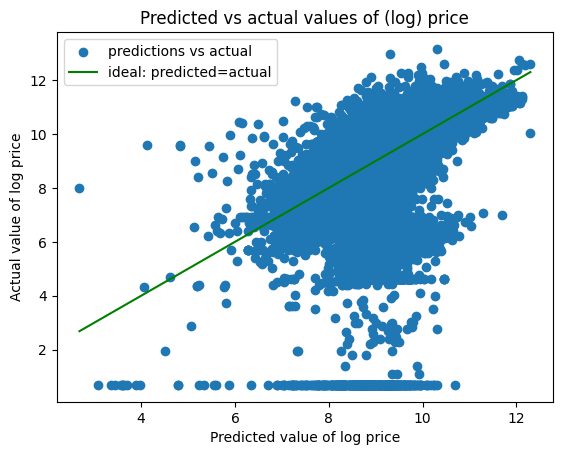

In [15]:
# We show a scatter plot of predicted vs actual prices:

plt.scatter(y_preds , y_test , color='tab:blue', label='predictions vs actual')
x_continuous = np.linspace(np.min(y_preds),np.max(y_preds),1000)
plt.plot( x_continuous , x_continuous , color='green' , label='ideal: predicted=actual' )
plt.xlabel('Predicted value of log price'); plt.ylabel('Actual value of log price'); plt.title('Predicted vs actual values of (log) price'); plt.legend()
plt.savefig('plots/predicted_vs_actual_logprice.png'); plt.show()



### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

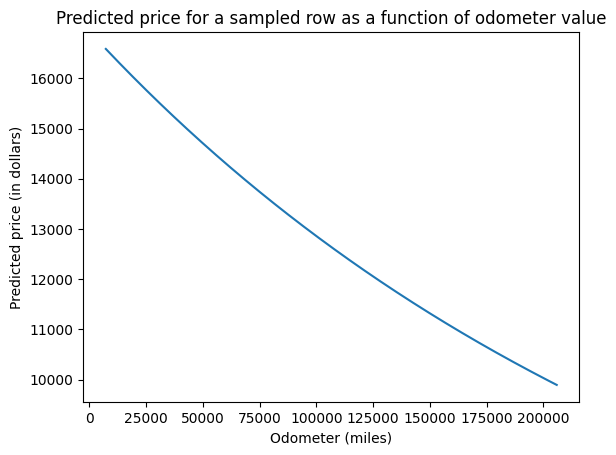

In [16]:
## Graph showing how the predicted price contribution depends on the odometer value

# Note: the predictions can take about 10 seconds to run.

sample = X_test.sample().copy() # randomly pick a row from sample. We'll keep all the non-odometer values constant to produce the graph
x_vals = np.linspace(X_train['odometer'].quantile(0.05), X_train['odometer'].quantile(0.95), 500)
preds = []
for x in x_vals:
    row = sample.copy()
    row['odometer'] = x
    # use the best model to predict pricing from the sampled row, with odometer varying through x_vals
    pred = bestmodel.predict(row)[0]     
    preds.append(pred)
plt.plot(x_vals, np.expm1(preds))
plt.xlabel("Odometer (miles)"); plt.ylabel("Predicted price (in dollars)"); plt.title('Predicted price for a sampled row as a function of odometer value')
plt.savefig('plots/predicted_price_vs_odometer_value.png'); plt.show()

comment="""
 In general, we see that the predicted price decreases steadily as the odometer value increases.
"""



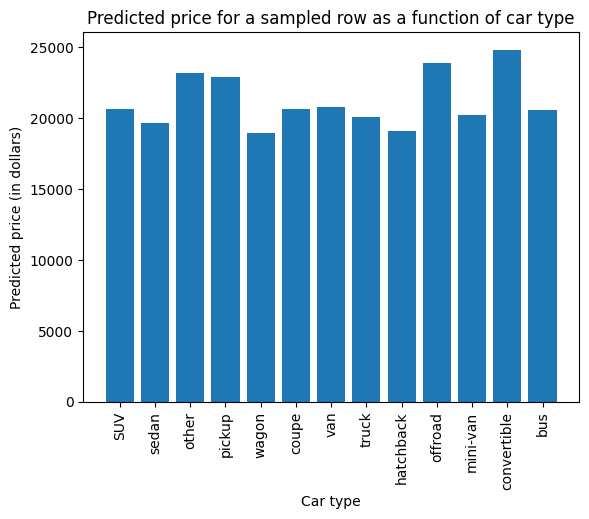

In [17]:
## Bar chart showing predicted price vs car type

sample = X_test.sample().copy() # randomly pick a row from sample. We'll keep all the non-odometer values constant to produce the graph
x_vals = X_train['type'].dropna().unique()
preds = []
for x in x_vals:
    row = sample.copy()
    row['type'] = x
    # use the best model to predict pricing from the sampled row, with odometer varying through x_vals
    pred = bestmodel.predict(row)[0]     
    preds.append(pred)
plt.bar(x_vals, np.expm1(preds))
plt.xlabel("Car type"); plt.ylabel("Predicted price (in dollars)"); plt.xticks(rotation='vertical'); plt.title('Predicted price for a sampled row as a function of car type')
plt.savefig('plots/predicted_price_vs_car_type.png', bbox_inches='tight'); plt.show()

comment="""
 In general, we see that pickups, convertibles, and offroad vehicles have a higher predicted price.
"""


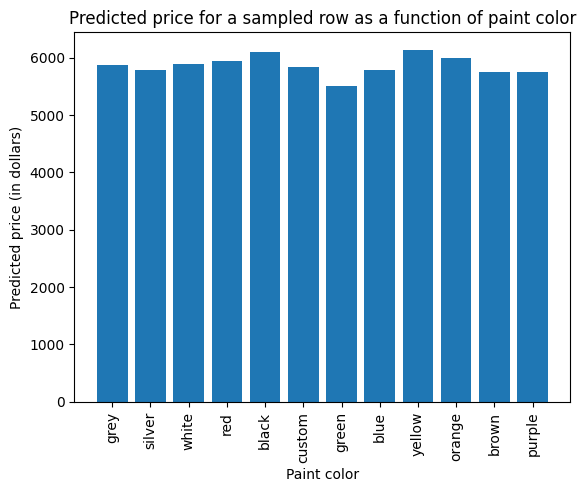

In [18]:
## Bar chart showing predicted price vs paint color

sample = X_test.sample().copy() # randomly pick a row from sample. We'll keep all the non-odometer values constant to produce the graph
x_vals = X_train['paint_color'].dropna().unique()
preds = []
for x in x_vals:
    row = sample.copy()
    row['paint_color'] = x
    # use the best model to predict pricing from the sampled row, with odometer varying through x_vals
    pred = bestmodel.predict(row)[0]     
    preds.append(pred)
plt.bar(x_vals, np.expm1(preds))
plt.xlabel("Paint color"); plt.ylabel("Predicted price (in dollars)"); plt.xticks(rotation='vertical'); plt.title('Predicted price for a sampled row as a function of paint color')
plt.savefig('plots/predicted_price_vs_paint_color.png', bbox_inches='tight'); plt.show()

comment="""
 In general, we see that black, yellow, and orange cars have higher prices, whereas green cars have lower prices.
"""


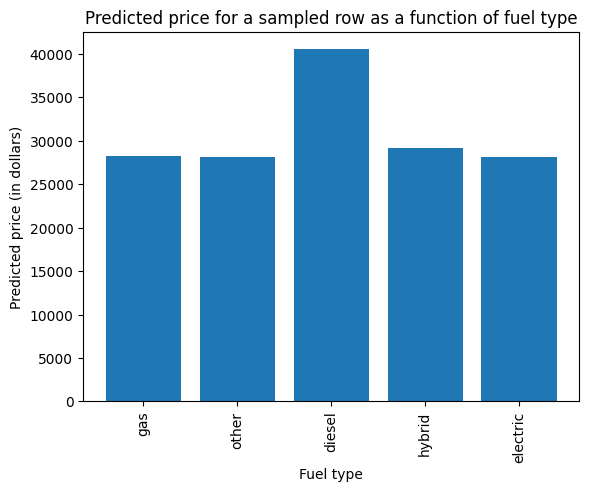

In [19]:
## Bar chart showing predicted price vs fuel type

sample = X_test.sample().copy() # randomly pick a row from sample. We'll keep all the non-odometer values constant to produce the graph
x_vals = X_train['fuel'].dropna().unique()
preds = []
for x in x_vals:
    row = sample.copy()
    row['fuel'] = x
    # use the best model to predict pricing from the sampled row, with odometer varying through x_vals
    pred = bestmodel.predict(row)[0]     
    preds.append(pred)
plt.bar(x_vals, np.expm1(preds))
plt.xlabel("Fuel type"); plt.ylabel("Predicted price (in dollars)"); plt.xticks(rotation='vertical'); plt.title('Predicted price for a sampled row as a function of fuel type')
plt.savefig('plots/predicted_price_vs_fuel_type.png', bbox_inches='tight'); plt.show()

comment="""
 In general, we see that diesel cars have a noticeably higher price than other cars.
"""


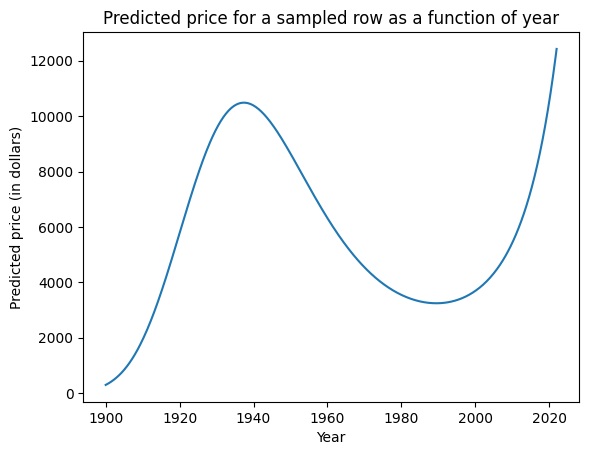

In [21]:
## Graph showing how the predicted price contribution depends on year

# Note: the predictions can take about 10 seconds to run.

sample = X_test.sample().copy() # randomly pick a row from sample. We'll keep all the non-odometer values constant to produce the graph
x_vals = np.linspace(1900,2022, 511) # known min and max values of year column
preds = []
for x in x_vals:
    row = sample.copy()
    row['years_before_2020'] = 2020-x
    # use the best model to predict pricing from the sampled row, with odometer varying through x_vals
    pred = bestmodel.predict(row)[0]     
    preds.append(pred)
plt.plot(x_vals, np.expm1(preds))
plt.xlabel("Year"); plt.ylabel("Predicted price (in dollars)"); plt.title('Predicted price for a sampled row as a function of year')
plt.savefig('plots/predicted_price_vs_year.png'); plt.show()

comment="""
 In general, we see that the predicted price is low around 1900, reaches a peak around 1935, goes down to another trough at 1990, then increases greatly until 2022.
"""

